##Ejercicio1: Caso A

Vector original  p  = [1 2 0]
Vector resultante p' = [-2  1  0]


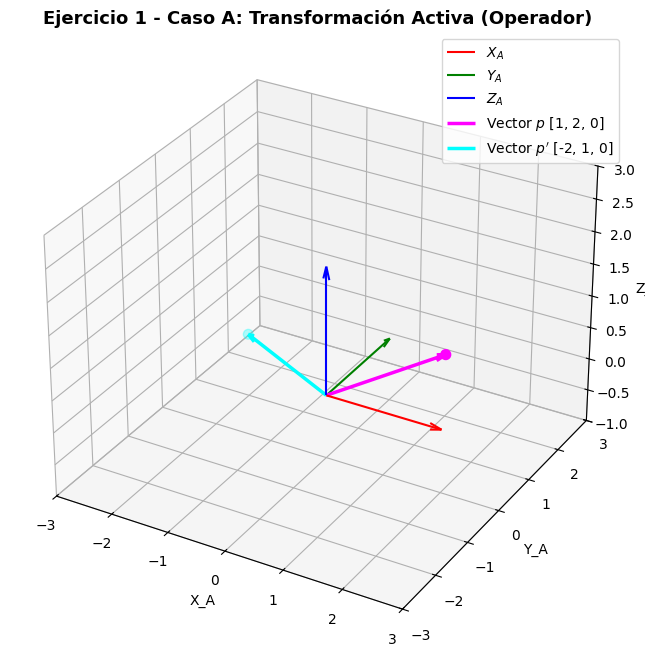

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definición del vector original y la matriz de rotación Rz(90°)
p = np.array([1, 2, 0])
Rz_90 = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])

# Transformación Activa: p' = R * p
p_prime = Rz_90 @ p

print(f"Vector original  p  = {p}")
print(f"Vector resultante p' = {p_prime}")

#GRÁFICA 3D: CASO A
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar Ejes del Marco {A}
ax.quiver(0, 0, 0, 2, 0, 0, color='red', arrow_length_ratio=0.1, label='$X_A$')
ax.quiver(0, 0, 0, 0, 2, 0, color='green', arrow_length_ratio=0.1, label='$Y_A$')
ax.quiver(0, 0, 0, 0, 0, 2, color='blue', arrow_length_ratio=0.1, label='$Z_A$')

# Dibujar Vector Original p y Vector Rotado p'
ax.quiver(0, 0, 0, p[0], p[1], p[2], color='magenta', linewidth=2.5, arrow_length_ratio=0.08, label='Vector $p$ [1, 2, 0]')
ax.quiver(0, 0, 0, p_prime[0], p_prime[1], p_prime[2], color='cyan', linewidth=2.5, arrow_length_ratio=0.08, label="Vector $p'$ [-2, 1, 0]")

# Puntos en los extremos
ax.scatter([p[0], p_prime[0]], [p[1], p_prime[1]], [p[2], p_prime[2]], color=['magenta', 'cyan'], s=50)

# Configuraciones del gráfico
ax.set_title('Ejercicio 1 - Caso A: Transformación Activa (Operador)', fontsize=13, fontweight='bold')
ax.set_xlabel('X_A')
ax.set_ylabel('Y_A')
ax.set_zlabel('Z_A')
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-1, 3])
ax.grid(True)
ax.legend(loc='upper right')
plt.show()

##Ejercicio1: Caso B

Coordenadas en Marco {B}: p_B = [1 2 0]
Coordenadas en Marco {A}: p_A = [-2  1  0]


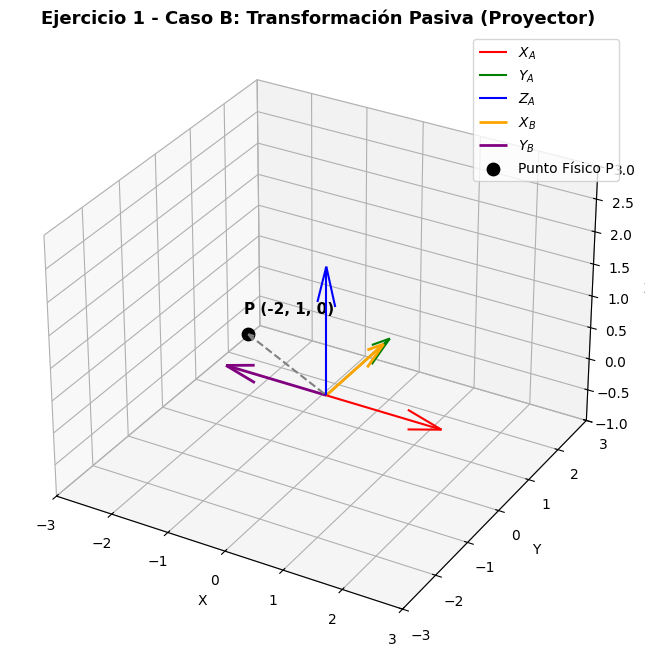

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Coordenadas locales y Matriz de Rotación de B respecto a A
p_B = np.array([1, 2, 0])
A_R_B = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])

# Cálculo de coordenadas globales: p_A = A_R_B * p_B
p_A = A_R_B @ p_B

print(f"Coordenadas en Marco {{B}}: p_B = {p_B}")
print(f"Coordenadas en Marco {{A}}: p_A = {p_A}")

#GRÁFICA 3D: CASO B
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Marco Fijo {A} en el origen (Líneas sólidas)
ax.quiver(0, 0, 0, 2, 0, 0, color='red', linestyle='-', linewidth=1.5, label='$X_A$')
ax.quiver(0, 0, 0, 0, 2, 0, color='green', linestyle='-', linewidth=1.5, label='$Y_A$')
ax.quiver(0, 0, 0, 0, 0, 2, color='blue', linestyle='-', linewidth=1.5, label='$Z_A$')

# Marco Móvil {B} (Rotado 90° sobre Z_A)
# X_B se alinea con Y_A, Y_B se alinea con -X_A, Z_B coincide con Z_A
ax.quiver(0, 0, 0, A_R_B[0,0]*1.8, A_R_B[1,0]*1.8, A_R_B[2,0]*1.8, color='orange', linewidth=2, label='$X_B$')
ax.quiver(0, 0, 0, A_R_B[0,1]*1.8, A_R_B[1,1]*1.8, A_R_B[2,1]*1.8, color='purple', linewidth=2, label='$Y_B$')

# Punto físico P en el espacio
ax.scatter([p_A[0]], [p_A[1]], [p_A[2]], color='black', s=80, label='Punto Físico P')
ax.text(p_A[0]-0.2, p_A[1]+0.2, p_A[2]+0.2, "P (-2, 1, 0)", fontsize=11, fontweight='bold')

# Vector desde el origen al punto P
ax.quiver(0, 0, 0, p_A[0], p_A[1], p_A[2], color='gray', linestyle='--', arrow_length_ratio=0.08)

# Configuración del gráfico
ax.set_title('Ejercicio 1 - Caso B: Transformación Pasiva (Proyector)', fontsize=13, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-1, 3])
ax.grid(True)
ax.legend(loc='upper right')
plt.show()

##Ejercicio3

In [ ]:
import numpy as np
from fractions import Fraction

# Configuración básica de impresión en NumPy
np.set_printoptions(precision=4, suppress=True)



# 1. FUNCIÓN PARA MOSTRAR FRACCIONES Y VALORES EXACTOS

def a_fraccion_o_exacto(val: float, tol: float = 1e-5) -> str:
    if abs(val) < tol:
        return "0"

    signo = "-" if val < 0 else ""
    abs_v = abs(val)

    # Diccionario de valores irracionales y fraccionarios comunes en rotaciones
    valores_conocidos = {
        0.5: "1/2",
        np.sqrt(2)/2: "√2/2",
        np.sqrt(3)/2: "√3/2",
        1.0: "1"
    }

    # Comprobar si coincide con un valor notable trigonométrico
    for num, texto in valores_conocidos.items():
        if abs(abs_v - num) < tol:
            return f"{signo}{texto}"

    # Si es un racional ordinario, convertir a fracción entera
    frac = Fraction(val).limit_denominator(100)
    return str(frac)

def imprimir_matriz_fracciones(matriz: np.ndarray, nombre: str = "Matriz"):
    print(f"{nombre} (EN FRACCIÓN)")

    # Si es un vector de 1D
    if matriz.ndim == 1:
        elem_str = [a_fraccion_o_exacto(x) for x in matriz]
        print("[" + ", ".join(f"{s:>7s}" for s in elem_str) + " ]^T\n")
        return

    # Si es una matriz de 2D
    for fila in matriz:
        elem_str = [a_fraccion_o_exacto(x) for x in fila]
        print("[ " + ", ".join(f"{s:>7s}" for s in elem_str) + " ]")
    print()

# 2. FUNCIONES CANÓNICAS DE ROTACIÓN (SO(3))

def rot_x(deg: float) -> np.ndarray:
    rad = np.radians(deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(rad), -np.sin(rad)],
        [0, np.sin(rad), np.cos(rad)]
    ])

def rot_y(deg: float) -> np.ndarray:
    rad = np.radians(deg)
    return np.array([
        [np.cos(rad), 0, np.sin(rad)],
        [0, 1, 0],
        [-np.sin(rad), 0, np.cos(rad)]
    ])

def rot_z(deg: float) -> np.ndarray:
    rad = np.radians(deg)
    return np.array([
        [np.cos(rad), -np.sin(rad), 0],
        [np.sin(rad), np.cos(rad), 0],
        [0, 0, 1]
    ])

# 3. COMPOSICIÓN Y MUESTRA DE RESULTADOS

# Cálculo de la composición del Ejercicio 2
A_R_B = rot_y(-45) @ rot_x(45) @ rot_z(90)

# Muestra en formato decimal y en formato fraccionario
print("MATRIZ EN DECIMAL")
print(A_R_B)
print()

imprimir_matriz_fracciones(A_R_B, nombre="MATRIZ ^A R_B")

# 4. TRANSFORMACIÓN DEL VECTOR p_B Y MUESTRA EN FRACCIONES

p_B = np.array([2, -1, 4])
p_A = A_R_B @ p_B

print("TRANSFORMACIÓN DE VECTOR")
print(f"Vector original p_B  : {p_B}")
print(f"Vector transformado p_A (Decimal): {np.round(p_A, 4)}")
imprimir_matriz_fracciones(p_A, nombre="Vector p_A")


# 5. VALIDACIONES NUMÉRICAS
# Ortogonalidad (Norma de Frobenius)
error_ortogonalidad = np.linalg.norm(A_R_B.T @ A_R_B - np.eye(3), ord='fro')
assert error_ortogonalidad < 1e-15, "Fallo en ortogonalidad"

# Isometría (Conservación de norma)
diferencia_norma = np.linalg.norm(p_A) - np.linalg.norm(p_B)
assert np.isclose(diferencia_norma, 0.0), "Fallo en la conservación de norma"

print("VALIDACIONES")
print(f"• Error Ortogonalidad ||R^T * R - I||_F : {error_ortogonalidad:.2e}")
print(f"• Diferencia de normas ||p_A|| - ||p_B||  : {diferencia_norma:.2e}")

MATRIZ EN DECIMAL
[[-0.5    -0.7071 -0.5   ]
 [ 0.7071  0.     -0.7071]
 [ 0.5    -0.7071  0.5   ]]

MATRIZ ^A R_B (EN FRACCIÓN)
[    -1/2,   -√2/2,    -1/2 ]
[    √2/2,       0,   -√2/2 ]
[     1/2,   -√2/2,     1/2 ]

TRANSFORMACIÓN DE VECTOR
Vector original p_B  : [ 2 -1  4]
Vector transformado p_A (Decimal): [-2.2929 -1.4142  3.7071]
Vector p_A (EN FRACCIÓN)
[-227/99, -140/99,  367/99 ]^T

VALIDACIONES
• Error Ortogonalidad ||R^T * R - I||_F : 1.57e-16
• Diferencia de normas ||p_A|| - ||p_B||  : 0.00e+00
